# 06 - DBSCAN Cosine

Clustering berbasis **kepadatan** dengan jarak Cosine. Jumlah klaster muncul
otomatis. PCA 2D dipakai **hanya untuk visualisasi**.

## Alur

```
X_scaled
   ↓  grid search kecil: eps & min_samples
parameter terbaik
   ↓  DBSCAN
label klaster (+ noise)  →  PCA 2D  →  scatter
```

## Rumus & Konsep

$$d_{euclid}(x,y)=\sqrt{\sum_i (x_i-y_i)^2},\quad
d_{manhattan}(x,y)=\sum_i |x_i-y_i|,\quad
d_{cosine}(x,y)=1-\frac{x\cdot y}{\lVert x\rVert\lVert y\rVert}$$

DBSCAN punya 2 parameter: `eps` ($\varepsilon$) = radius tetangga, dan
`min_samples` = jumlah minimal titik dalam radius agar jadi **core point**.

- **Core point**: tetangga dalam radius $\varepsilon$ >= `min_samples`
- **Border point**: bukan core tapi dekat core
- **Noise**: tidak keduanya (label $-1$)

**k-distance graph** membantu memilih `eps`: urutkan jarak tiap titik ke
tetangga ke-`min_samples`, cari titik tekukan.

## 0. Import & Muat Data

In [1]:
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

folder = 'Clustering_Stok'
LABEL = {'euclidean': 'Euclidean (L2)', 'manhattan': 'Manhattan (L1)', 'cosine': 'Cosine'}
GRID_EPS = {'euclidean': np.arange(1.0, 4.01, 0.5),
            'manhattan': np.arange(2.0, 8.01, 1.0),
            'cosine': np.arange(0.05, 0.51, 0.05)}
MIN_SAMPLES = [3, 5, 8]

In [2]:
X_df = pd.read_csv(f'{folder}/X_scaled.csv')
fitur = json.load(open(f'{folder}/meta.json'))['features']
X = X_df[fitur].values
data_asli = pd.read_csv(f'{folder}/fitur_produk_outlet.csv')
print('Jumlah produk-outlet :', X.shape[0])
print('Jumlah fitur         :', X.shape[1])

Jumlah produk-outlet : 282
Jumlah fitur         : 9


In [3]:
X_df.head()

,Outlet,Item,mean_daily,max_daily,trend_weekly_pct,weekend_ratio,momentum_30d,share_morning,share_evening,loyalty_share,avg_price
0,SHOP001,Air Mineral,1.322714,0.672432,-0.974961,-0.109107,-0.461093,0.166549,0.793543,-1.130617,-2.680986
1,SHOP001,Americano (Hot Arabica),1.511247,1.625325,-0.227430,0.609017,0.319884,0.107841,-0.430186,-1.130617,-0.305002
2,SHOP001,Americano (Hot Houseblend),0.782254,1.625325,-0.045790,0.579206,-0.298570,0.727303,0.343123,-1.130617,-0.305002
3,SHOP001,Americano (Ice Arabica),1.234732,0.672432,-0.884758,0.891666,-0.662410,0.501842,-0.654609,-1.130617,-0.305002
4,SHOP001,Americano (Ice Houseblend),1.372989,0.672432,-0.628443,-0.213534,0.060751,0.818590,-0.933467,-1.130617,-0.305002


## 1. Fungsi Bantu

- `cari_grid`: coba beberapa `eps` x `min_samples`, catat jumlah klaster, noise, Silhouette.
- `pilih_terbaik`: Silhouette tertinggi dengan minimal 2 klaster dan noise <= 30%.
- `plot_kdistance`: grafik k-distance untuk memeriksa `eps`.
- `jalankan`: jalankan DBSCAN, evaluasi (tanpa noise), simpan hasil.
- `plot_pca`: scatter 2D (noise ditandai abu-abu).

In [4]:
def cari_grid(metric):
    hasil = []
    for ms in MIN_SAMPLES:
        for eps in GRID_EPS[metric]:
            lab = DBSCAN(eps=eps, min_samples=ms, metric=metric).fit_predict(X)
            n_kl = len(set(lab)) - (1 if -1 in lab else 0)
            noise = (lab == -1).mean() * 100
            sil = np.nan
            if n_kl >= 2:
                ok = lab != -1
                sil = silhouette_score(X[ok], lab[ok], metric=metric)
            hasil.append({'eps': round(eps, 3), 'min_samples': ms,
                          'n_klaster': n_kl, 'noise_%': round(noise, 1), 'silhouette': sil})
    return pd.DataFrame(hasil)


def pilih_terbaik(grid):
    layak = grid[(grid['n_klaster'] >= 2) & (grid['noise_%'] <= 30)].sort_values('silhouette', ascending=False)
    terbaik = layak.iloc[0]
    return terbaik['eps'], int(terbaik['min_samples'])


def plot_kdistance(metric, ms, eps):
    jarak, _ = NearestNeighbors(n_neighbors=ms, metric=metric).fit(X).kneighbors(X)
    k_distance = np.sort(jarak[:, -1])
    plt.plot(k_distance, label=f'jarak ke tetangga ke-{ms}')
    plt.axhline(eps, color='red', linestyle='--', label=f'eps = {eps}')
    plt.title(f'k-distance - {LABEL[metric]}')
    plt.xlabel('Titik data (terurut)')
    plt.ylabel(f'Jarak ke tetangga ke-{ms}')
    plt.legend()
    plt.show()


def jalankan(metric, eps, ms):
    mulai = time.perf_counter()
    label = DBSCAN(eps=eps, min_samples=ms, metric=metric).fit_predict(X)
    waktu = time.perf_counter() - mulai

    ok = label != -1
    n_kl = len(set(label)) - (1 if -1 in label else 0)
    noise = (label == -1).mean() * 100
    sil = silhouette_score(X[ok], label[ok], metric=metric)
    sil_euc = silhouette_score(X[ok], label[ok], metric='euclidean')   # pembanding adil
    db = davies_bouldin_score(X[ok], label[ok])
    ch = calinski_harabasz_score(X[ok], label[ok])

    nama = f'DBSCAN-{metric}'
    pd.DataFrame({'Outlet': X_df['Outlet'], 'Item': X_df['Item'], 'cluster': label}).to_csv(f'{folder}/labels_{nama}.csv', index=False)
    ring = {'Model': nama, 'Algoritma': 'DBSCAN', 'Metrik': LABEL[metric], 'Parameter': f'eps={eps}, min_samples={ms}',
            'Jumlah Klaster': n_kl, 'Noise (%)': round(noise, 2),
            'Silhouette (own)': round(sil, 4), 'Silhouette (Euclid)': round(sil_euc, 4),
            'Davies-Bouldin': round(db, 4), 'Calinski-Harabasz': round(ch, 2), 'Waktu (s)': round(waktu, 5)}
    pd.DataFrame([ring]).to_csv(f'{folder}/eval_{nama}.csv', index=False)
    return label, ring


def plot_pca(labels, judul):
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X)
    plt.figure(figsize=(9, 6))
    for c in sorted(set(labels)):
        m = labels == c
        if c == -1:
            plt.scatter(X2[m, 0], X2[m, 1], marker='x', s=40, c='gray', label=f'Noise (n={m.sum()})')
        else:
            plt.scatter(X2[m, 0], X2[m, 1], s=45, alpha=0.75, label=f'Klaster {c} (n={m.sum()})')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)')
    plt.title(judul)
    plt.legend()
    plt.show()

## 2. DBSCAN Cosine

In [5]:
grid_cos = cari_grid('cosine')
eps_cos, ms_cos = pilih_terbaik(grid_cos)
print(f'eps terpilih = {eps_cos}, min_samples terpilih = {ms_cos}')

eps terpilih = 0.2, min_samples terpilih = 3


/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/ven

/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


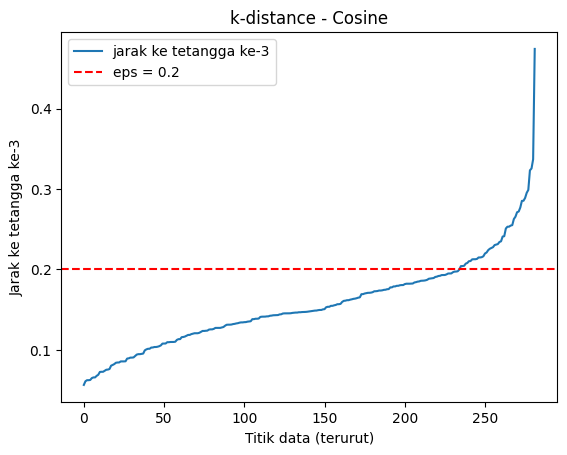

In [6]:
plot_kdistance('cosine', ms_cos, eps_cos)

In [7]:
label_cos, ring_cos = jalankan('cosine', eps_cos, ms_cos)
pd.DataFrame([ring_cos]).T

/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vanesshh/Downloads/Quiz 2/ven

,0
Model,DBSCAN-cosine
Algoritma,DBSCAN
Metrik,Cosine
Parameter,"eps=0.2, min_samples=3"
Jumlah Klaster,3
Noise (%),9.22
Silhouette (own),0.1661
Silhouette (Euclid),0.0364
Davies-Bouldin,1.7802
Calinski-Harabasz,31.59


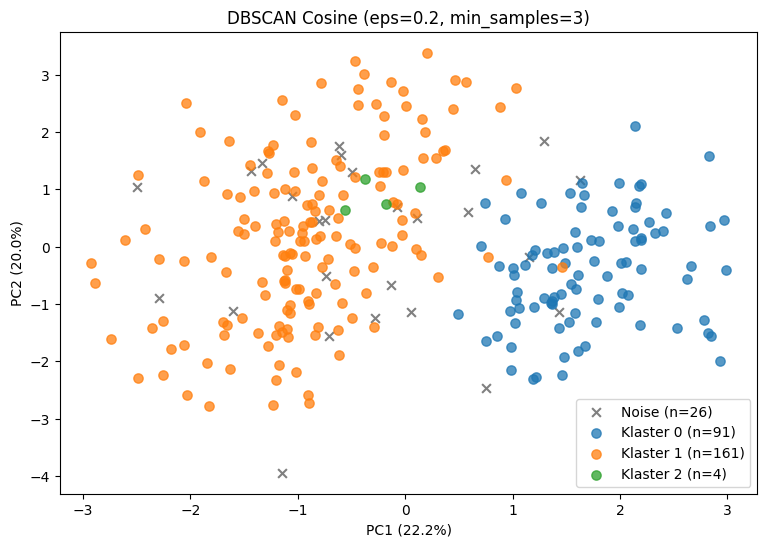

In [8]:
plot_pca(label_cos, f'DBSCAN Cosine (eps={eps_cos}, min_samples={ms_cos})')

## 3. Tabel Hasil

Metrik dihitung **tanpa titik noise**. Noise (-1) = produk dengan pola
permintaan tidak biasa, bukan dibuang tapi perlu dipantau khusus.

In [9]:
kolom = ['Metrik', 'Parameter', 'Jumlah Klaster', 'Noise (%)', 'Silhouette (own)',
         'Silhouette (Euclid)', 'Davies-Bouldin', 'Calinski-Harabasz', 'Waktu (s)']
pd.DataFrame([ring_cos])[kolom]

,Metrik,Parameter,Jumlah Klaster,Noise (%),Silhouette (own),Silhouette (Euclid),Davies-Bouldin,Calinski-Harabasz,Waktu (s)
0,Cosine,"eps=0.2, min_samples=3",3,9.22,0.1661,0.0364,1.7802,31.59,0.00158


## Kesimpulan

DBSCAN Cosine menemukan jumlah klaster otomatis dan menandai sebagian data sebagai noise. Hasil disimpan di folder `Clustering_Stok` untuk dibandingkan di `07_Perbandingan.ipynb`.